In [23]:
import os
import random
import numpy as np
import tensorflow as tf

os.environ["PYTHONHASHSEED"] = "42"

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [24]:
import numpy as np
import pandas as pd
import tensorflow as tf
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [25]:
X,y = make_circles(n_samples = 100,noise = 0.1, random_state =1)

<Axes: >

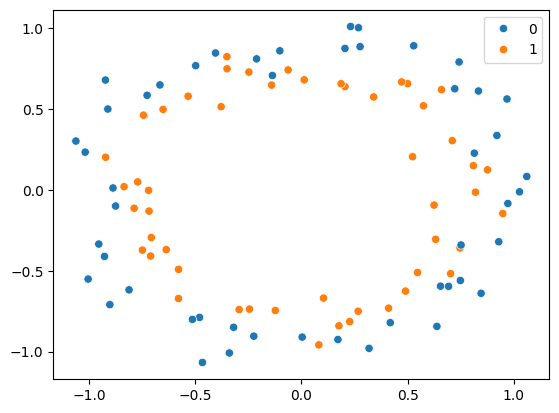

In [26]:
sns.scatterplot(x = X[:,0],y = X[:,1],hue=y)

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 2)

In [28]:
model = Sequential()

model.add(Dense(256,input_dim =2, activation='relu'))
model.add(Dense(1,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [31]:
history = model.fit(X_train,y_train,validation_data = (X_test,y_test), epochs = 3500,verbose = 0)

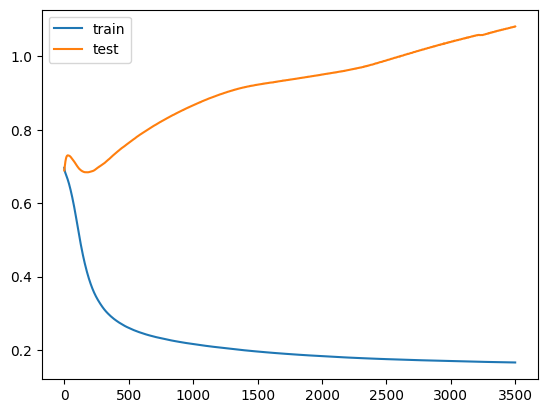

In [32]:
plt.plot(history.history['loss'],label= 'train')
plt.plot(history.history['val_loss'], label = 'test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


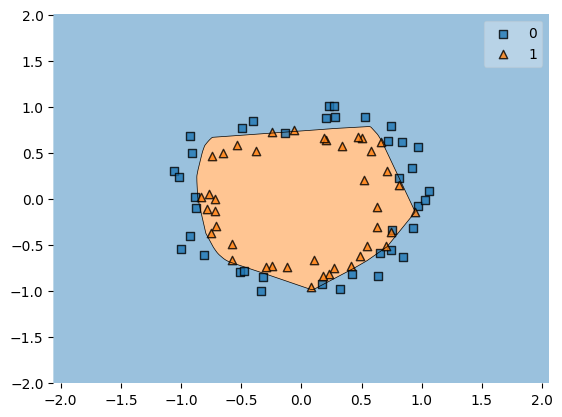

In [33]:
plot_decision_regions(X_train,y_train,clf = model)
plt.show()

# Early Stopping


In [34]:
model = Sequential()

model.add(Dense(256,input_dim = 2 , activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))

In [35]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [36]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [37]:
history = model.fit(X_train,y_train,validation_data = (X_test,y_test), epochs = 3500, callbacks = callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5000 - loss: 0.6952 - val_accuracy: 0.5500 - val_loss: 0.6885
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5125 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5375 - loss: 0.6904 - val_accuracy: 0.4000 - val_loss: 0.6963
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5500 - loss: 0.6886 - val_accuracy: 0.4500 - val_loss: 0.7000
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5500 - loss: 0.6870 - val_accuracy: 0.4500 - val_loss: 0.7035
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5625 - loss: 0.6856 - val_accuracy: 0.4000 - val_loss: 0.7069
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5625 - loss: 0.6843 - val_accuracy: 0.4000 - val_loss: 0.7099
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5625 - loss: 0.6831 - val_accuracy: 0.4000 - 

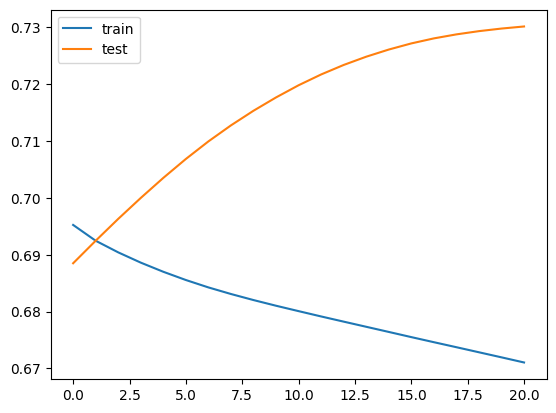

In [38]:
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'],label = 'test')
plt.legend()
plt.show()